# BTCUSDT aggregate-flow impact scaling

This notebook asks whether BTCUSDT exhibits a concave, power-law-like price response to aggressive signed flow.  It then continues to investigate what the best functional form for estimating price response.

The primary estimand is the conditional **signed** response:

$$
E\left[\operatorname{sign}(Q_t)r_t/\sigma_t \mid |Q_t|/V_t\right],
$$

where $Q_t$ is signed imbalance within a fixed 4,000-event bar, $V_t$ is trailing 24-hour market volume, and $\sigma_t$ is trailing 24-hour realised volatility. Both benchmarks are backward-looking and exclude the current bar.

This is not a direct replication of the metaorder square-root law. Binance public trades do not identify the parent decision behind each child trade, so the bars contain anonymous aggregate order flow. The result should therefore be described as an **aggregate-flow impact scaling relationship**, not causal impact from identified metaorders.

The notebook proceeds in four stages:

1. retain the absolute-return/absolute-imbalance plots as noise and shape diagnostics;
2. estimate the normalized conditional signed-impact curve;
3. compare square-root, free-power, linear and logarithmic descriptions;
4. test stability across months and gross-volume regimes using day-block bootstrap uncertainty and shared x-axis bins.


## Relation to the published square-root literature

The benchmark is Tóth et al.'s normalized metaorder relation,

$$
\Delta/\sigma = Y(Q/V)^\delta,
$$

with $\delta$ commonly near one half. Their $Q$ is the size of an identified parent order, $V$ is contemporaneous daily volume and $\sigma$ is daily volatility. They explicitly distinguish this from price change measured against anonymous market-order imbalance over a fixed interval, noting that the latter can become more linear as the interval grows. Their reported futures fits also cover a limited $Q/V$ range and depend on impact definition, pooling, intercept treatment and fit range.

Donier and Bonart's Bitcoin result uses trader identifiers to reconstruct metaorders, checks execution schedules and concurrent order flow, and then studies aggregate imbalance during those identified trajectories. Binance public trades do not supply the equivalent parent-order identifiers.

Zarinelli et al. apply liquidity, time, duration and participation filters, explicitly remove a noisy low-participation region in one analysis, and find that a logarithmic curve can outperform a power law over a sufficiently wide range. For that reason this notebook reports the full low-flow diagnostic, uses predetermined measurement filters, and compares rather than assumes functional forms.

References: [Tóth et al.](https://arxiv.org/abs/1105.1694), [Donier and Bonart](https://arxiv.org/abs/1412.4503), and [Zarinelli et al.](https://arxiv.org/abs/1412.2152).


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

%matplotlib inline

# Make imports work whether the notebook is opened from notebooks/ or from the project root.
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
for path in (PROJECT_DIR, PROJECT_DIR / "src"):  # src/: modules import each other as crypto_impact.*
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from src.crypto_impact.binning import (
    bin_impact_by_shared_edges,
    bin_impact_curve_with_uncertainty,
)
from src.crypto_impact.impact import (
    add_normalised_impact_trajectories,
    add_trailing_impact_normalisation,
    summarise_normalised_impact_trajectory,
)
from src.crypto_impact.monthly_eda import (
    load_monthly_trades, 
    make_trade_bars,
    make_time_bars,
    build_fixed_event_bars,
)
from src.crypto_impact.regime_analysis import (
    add_market_regimes,
    build_analysis_table,
    fit_regression,
)
from src.crypto_impact.regression import compare_impact_models
from src.crypto_impact.shape import (
    block_bootstrap_impact_models,
    compare_impact_models_by_regime,
)

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")


## Load or build fixed-trade-count bars

If a `bars` DataFrame already exists in the notebook kernel, this cell will reuse it. Otherwise it builds bars from the monthly parquet files.

For a quick first run, set `MAX_FILES = 1`. For the full sample, set `MAX_FILES = None`.

In [2]:
import os

# Corrected trade events (one event per same-sign run of fills at a millisecond
# timestamp, priced at the run's last fill; scripts/export_paper_events.py), on the
# shared data drive. The legacy files in data/raw/BTCUSDT_monthly (first-fill price
# and sign per timestamp, 2025-01..2026-05) are no longer used.
SHARED_ACADEMIC = PROJECT_DIR.parent / "shared-data" / "features" / "academic" / "symbol=BTCUSDT"
DATA_DIR = Path(os.environ.get("CRYPTO_IMPACT_DATA_DIR", SHARED_ACADEMIC / "paper_events_v2"))
SAMPLE_START = os.environ.get("CRYPTO_IMPACT_SAMPLE_START", "2021-01")
SAMPLE_END = os.environ.get("CRYPTO_IMPACT_SAMPLE_END", "2026-08")
assert SAMPLE_END <= "2026-08", "Data from 2026-09 onward is reserved for the alpha-search P-006 test."
TRADES_PER_BAR = 4_000
MAX_FILES = None  # use 1 for a quick smoke run; None for all files

# Redo outputs sit beside the other full-sample notebook reruns, so the paper's
# original reports/figures are not overwritten.
FIGURE_DIR = Path(os.environ.get("CRYPTO_IMPACT_FIGURE_DIR", PROJECT_DIR / "reports" / "redo" / "paper" / "figures"))
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

files = sorted(
    path for path in DATA_DIR.glob("BTCUSDT-trades-*.parquet")
    if SAMPLE_START <= path.stem.removeprefix("BTCUSDT-trades-") <= SAMPLE_END
)
if MAX_FILES is not None:
    files = files[:MAX_FILES]

print(f"Files selected: {len(files)}")
print(files[:3])

Files selected: 68
[PosixPath('/Users/petermillington/phd/market-impact-research/shared-data/features/academic/symbol=BTCUSDT/paper_events_v2/BTCUSDT-trades-2021-01.parquet'), PosixPath('/Users/petermillington/phd/market-impact-research/shared-data/features/academic/symbol=BTCUSDT/paper_events_v2/BTCUSDT-trades-2021-02.parquet'), PosixPath('/Users/petermillington/phd/market-impact-research/shared-data/features/academic/symbol=BTCUSDT/paper_events_v2/BTCUSDT-trades-2021-03.parquet')]


In [3]:
bars = build_fixed_event_bars(
    files,
    events_per_bar=TRADES_PER_BAR,
)

bars.head()

,end_time,start_price,end_price,high_price,low_price,gross_volume,signed_imbalance,trade_count,duration_seconds,log_return_bps,abs_signed_imbalance,absolute_imbalance_ratio,high_low_range_bps,source_file,events_per_bar
start_time,,,,,,,,,,,,,,,
2021-01-01 00:00:00.001000+00:00,2021-01-01 00:08:29.846000+00:00,"28,948.190000","28,929.560000","29,045.930000","28,904.000000",994.313000,46.303000,4000,509.845000,-6.437707,46.303000,0.046568,48.983764,BTCUSDT-trades-2021-01.parquet,4000
2021-01-01 00:08:29.880000+00:00,2021-01-01 00:13:57.189000+00:00,"28,927.450000","28,750.000000","28,948.370000","28,750.000000","1,343.352000",-589.516000,4000,327.309000,-61.532041,589.516000,0.438840,68.761312,BTCUSDT-trades-2021-01.parquet,4000
2021-01-01 00:13:57.197000+00:00,2021-01-01 00:18:04.891000+00:00,"28,750.010000","28,830.000000","28,841.000000","28,706.000000","1,549.984000",86.434000,4000,247.694000,27.783966,86.434000,0.055764,46.918257,BTCUSDT-trades-2021-01.parquet,4000
2021-01-01 00:18:04.942000+00:00,2021-01-01 00:26:08.649000+00:00,"28,829.990000","28,880.000000","28,902.680000","28,761.140000","1,241.123000",108.549000,4000,483.707000,17.331492,108.549000,0.087460,49.091539,BTCUSDT-trades-2021-01.parquet,4000
2021-01-01 00:26:08.656000+00:00,2021-01-01 00:36:42.986000+00:00,"28,878.950000","28,943.500000","28,955.100000","28,837.140000",983.487000,-4.529000,4000,634.330000,22.326977,4.529000,0.004605,40.822146,BTCUSDT-trades-2021-01.parquet,4000


## Build and normalize the analysis table

The table contains the raw bar variables, future returns and market regimes. It then adds backward-looking normalization:

- `signed_current_impact_bps`: current return multiplied by the sign of signed imbalance;
- `trailing_market_volume`: gross BTC volume in the preceding 24 hours;
- `trailing_realised_volatility_bps`: square root of summed squared bar returns in the preceding 24 hours;
- `normalised_imbalance`: `abs(signed_imbalance) / trailing_market_volume`;
- `normalised_signed_impact`: `signed_current_impact_bps / trailing_realised_volatility_bps`.

The first observations have missing normalized values until the trailing benchmark has enough history. No future information is used.


In [4]:
HORIZONS = [1, 2, 3, 5]
TRAILING_WINDOW = "1D"
MIN_TRAILING_BARS = 100

analysis = build_analysis_table(bars, horizons=HORIZONS)

analysis["signed_current_return_bps"] = (
    np.sign(analysis["signed_imbalance"]) * analysis["current_return_bps"]
)
analysis["log_abs_return"] = np.log(
    analysis["current_return_bps"].abs().replace(0, np.nan)
)
analysis["log_abs_imbalance"] = np.log(
    analysis["signed_imbalance"].abs().replace(0, np.nan)
)
analysis["log_absolute_imbalance_ratio"] = np.log(
    analysis["absolute_imbalance_ratio"].replace(0, np.nan)
)

analysis = add_trailing_impact_normalisation(
    analysis,
    window=TRAILING_WINDOW,
    min_periods=MIN_TRAILING_BARS,
    timestamp_col="end_time",
)
analysis = add_normalised_impact_trajectories(
    analysis,
    horizons=HORIZONS,
)
analysis = add_market_regimes(analysis)

analysis["block_day"] = pd.to_datetime(
    analysis["end_time"], utc=True
).dt.floor("D")
analysis.replace([np.inf, -np.inf], np.nan, inplace=True)

summary_cols = [
    "current_return_bps",
    "signed_imbalance",
    "gross_volume",
    "duration_seconds",
    "absolute_imbalance_ratio",
    "signed_current_impact_bps",
    "trailing_market_volume",
    "trailing_realised_volatility_bps",
    "normalised_imbalance",
    "normalised_signed_impact",
    "flow_rate_btc_per_second",
    "flow_rate_ratio",
]
analysis[summary_cols].describe(
    percentiles=[0.01, 0.1, 0.5, 0.9, 0.99]
).T


,count,mean,std,min,1%,10%,50%,90%,99%,max
current_return_bps,"583,799.000000",0.018846,19.701280,-678.843518,-50.456146,-22.077360,-0.051456,22.111735,51.264596,714.821548
signed_imbalance,"583,799.000000",-3.607071,333.077763,"-7,913.488000",-920.015260,-331.740200,-3.836000,325.819400,919.947100,"8,041.905000"
gross_volume,"583,799.000000","1,159.158830",575.138742,15.332000,382.306940,593.788800,"1,032.487000","1,865.470200","3,180.918360","12,110.345000"
duration_seconds,"583,799.000000",306.126203,269.661727,3.066000,16.867980,63.437000,234.448000,642.053800,"1,190.988860","59,910.544000"
absolute_imbalance_ratio,"583,799.000000",0.173752,0.125815,0.000000,0.002835,0.028568,0.151169,0.350772,0.529523,0.846199
signed_current_impact_bps,"583,799.000000",11.390817,16.074509,-392.262493,-21.281605,-5.295943,9.740881,29.649557,61.586770,714.821548
trailing_market_volume,"576,268.000000","425,501.184078","288,994.594595","43,770.564000","81,188.746560","152,870.455300","346,674.932500","792,926.816300","1,429,106.469070","2,455,631.351000"
trailing_realised_volatility_bps,"576,268.000000",353.131269,215.491990,52.793957,105.896681,169.938724,298.465447,584.515647,"1,160.278896","2,465.885390"
normalised_imbalance,"576,268.000000",0.000687,0.000932,0.000000,0.000007,0.000067,0.000413,0.001556,0.004334,0.037624
normalised_signed_impact,"576,268.000000",0.036333,0.049516,-0.554060,-0.069418,-0.017433,0.031864,0.095107,0.183273,1.090866


## Diagnostic: naive absolute-return regression

The following regression is retained because it reveals the geometry and noise in the raw data:

$$\log(|r|)=c+\alpha\log(|Q|)+\epsilon.$$

It is **not** the primary market-impact estimate. Absolute returns include unrelated volatility and prevent buy- and sell-side background moves from cancelling. Its exponent and $R^2$ should be treated as descriptive diagnostics.


In [5]:
power_sample = analysis[["log_abs_return", "log_abs_imbalance"]].dropna()

result_power_law = fit_regression(
    data=power_sample,
    target="log_abs_return",
    predictors=["log_abs_imbalance"],
    standardise=[],
    hac_lags=3,
)

print(result_power_law.model.summary())

alpha = result_power_law.model.params["log_abs_imbalance"]
r2 = result_power_law.model.rsquared
print(f"\nNaive full-sample exponent alpha: {alpha:.3f}")
print(f"R²: {r2:.3f}")

                            OLS Regression Results                            
Dep. Variable:         log_abs_return   R-squared:                       0.109
Model:                            OLS   Adj. R-squared:                  0.109
Method:                 Least Squares   F-statistic:                 5.069e+04
Date:                Thu, 08 Oct 2026   Prob (F-statistic):               0.00
Time:                        16:46:12   Log-Likelihood:            -8.7275e+05
No. Observations:              583356   AIC:                         1.745e+06
Df Residuals:                  583354   BIC:                         1.746e+06
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.7366      0.00

## Visualise the raw relationship

The raw scatter is very dense and heavily affected by microstructure noise. A hexbin plot is usually more useful than a normal scatter because it shows where the observations actually concentrate.

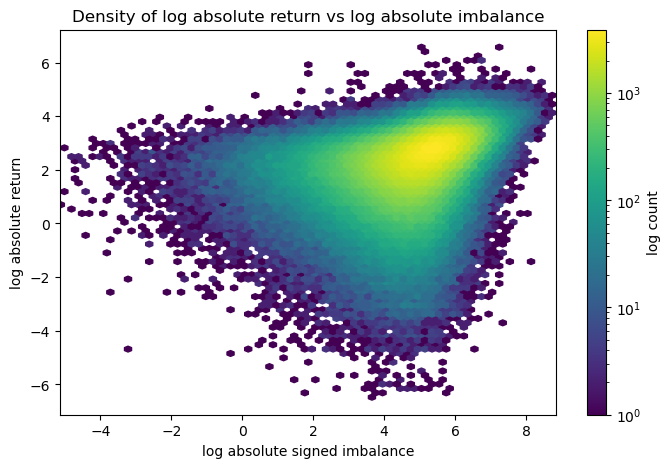

In [6]:


plot_data = analysis[["log_abs_imbalance", "log_abs_return", "signed_current_impact_bps"]].dropna().copy()

x_lower, x_upper = plot_data["log_abs_imbalance"].quantile(
    [0.00001, 0.99999]
)
# Bin only the plotted window: hexbin sizes its grid over the data's full range,
# so extreme outliers outside the window would otherwise coarsen the hexagons.
window = plot_data["log_abs_imbalance"].between(x_lower, x_upper)

plt.figure(figsize=(8, 5))
plt.hexbin(
    plot_data.loc[window, "log_abs_imbalance"],
    plot_data.loc[window, "log_abs_return"],
    gridsize=70,
    bins="log",
    cmap="viridis",
)
plt.colorbar(label="log count")

plt.xlim(x_lower, x_upper)

plt.xlabel("log absolute signed imbalance")
plt.ylabel("log absolute return")
plt.title("Density of log absolute return vs log absolute imbalance")

plt.savefig(FIGURE_DIR / "01_log_abs_return_vs_imbalance_hexbin.pdf")

plt.show()

## Diagnostic: binned absolute response

Equal-count bins make the wedge-shaped raw cloud easier to read. This chart shows where a concave association appears, but it still measures absolute price movement rather than signed response to flow.


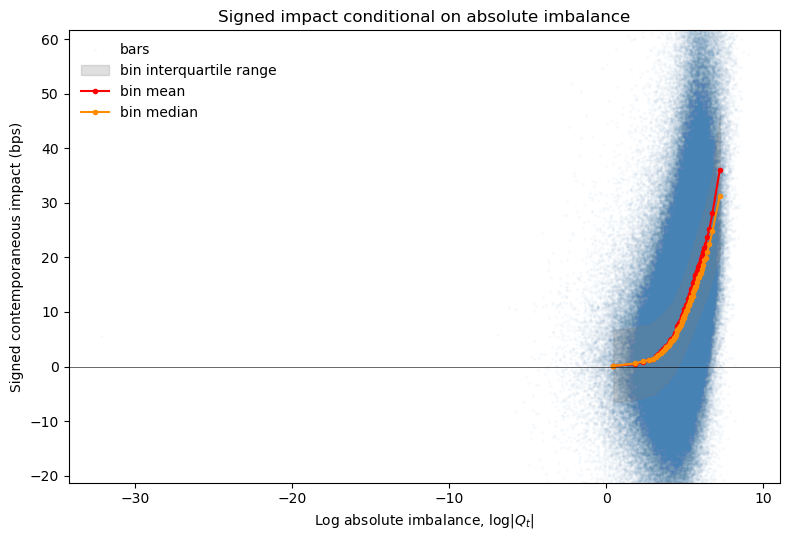

,mean_log_abs_imbalance,mean_current_impact,median_current_impact,p25_current_impact,p75_current_impact,count
0,0.434334,0.104977,0.125062,-6.562205,6.731053,9723
1,1.818149,0.460954,0.574343,-6.041442,7.138928,9723
2,2.342294,0.882873,0.985178,-5.708805,7.572609,9722
3,2.683711,1.270743,1.170813,-5.244892,7.468890,9723
4,2.938248,1.415269,1.310330,-5.273268,8.116305,9723


In [7]:
N_BINS = 60

plot_data["imbalance_bin"] = pd.qcut(
    plot_data["log_abs_imbalance"],
    q=N_BINS,
    duplicates="drop",
)

binned = (
    plot_data
    .groupby("imbalance_bin", observed=True)
    .agg(
        mean_log_abs_imbalance=("log_abs_imbalance", "mean"),
        mean_current_impact=("signed_current_impact_bps", "mean"),
        median_current_impact=("signed_current_impact_bps", "median"),
        p25_current_impact=("signed_current_impact_bps", lambda x: x.quantile(0.25)),
        p75_current_impact=("signed_current_impact_bps", lambda x: x.quantile(0.75)),
        count=("signed_current_impact_bps", "size"),
    )
    .reset_index(drop=True)
)

lower_y, upper_y = plot_data["signed_current_impact_bps"].quantile([0.01, 0.99])

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.scatter(
    plot_data["log_abs_imbalance"],
    plot_data["signed_current_impact_bps"],
    s=2,
    alpha=0.025,
    color="steelblue",
    rasterized=True,
    label="bars",
)

ax.fill_between(
    binned["mean_log_abs_imbalance"],
    binned["p25_current_impact"],
    binned["p75_current_impact"],
    color="grey",
    alpha=0.25,
    label="bin interquartile range",
)

ax.plot(
    binned["mean_log_abs_imbalance"],
    binned["mean_current_impact"],
    marker="o",
    markersize=3,
    color="red",
    linewidth=1.5,
    label="bin mean",
)

ax.plot(
    binned["mean_log_abs_imbalance"],
    binned["median_current_impact"],
    marker="o",
    markersize=3,
    color="darkorange",
    linewidth=1.5,
    label="bin median",
)

ax.axhline(0, color="black", linewidth=0.7, alpha=0.6)
ax.set_ylim(lower_y, upper_y)

ax.set_xlabel(r"Log absolute imbalance, $\log |Q_t|$")
ax.set_ylabel("Signed contemporaneous impact (bps)")
ax.set_title("Signed impact conditional on absolute imbalance")
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "02_binned_signed_impact_curve.pdf",
    bbox_inches="tight",
)
plt.show()

binned.head()

In [8]:
analysis.head()

,end_time,start_price,end_price,high_price,low_price,gross_volume,signed_imbalance,trade_count,duration_seconds,log_return_bps,abs_signed_imbalance,absolute_imbalance_ratio,high_low_range_bps,source_file,events_per_bar,signed_imbalance_ratio,log_duration,log_gross_volume,log_range,current_return_bps,future_return_1_bps,signed_future_return_1_bps,future_return_2_bps,signed_future_return_2_bps,future_return_3_bps,signed_future_return_3_bps,future_return_5_bps,signed_future_return_5_bps,signed_current_return_bps,log_abs_return,log_abs_imbalance,log_absolute_imbalance_ratio,trailing_market_volume,trailing_realised_volatility_bps,signed_current_impact_bps,normalised_imbalance,normalised_signed_impact,flow_rate_btc_per_second,trailing_volume_rate_btc_per_second,flow_rate_ratio,normalised_total_impact_0,normalised_post_response_0,normalised_post_response_1,normalised_total_impact_1,normalised_post_response_2,normalised_total_impact_2,normalised_post_response_3,normalised_total_impact_3,normalised_post_response_5,normalised_total_impact_5,absolute_imbalance_ratio_regime,activity_regime,duration_regime,volume_regime,volatility_regime,flow_rate_regime,normalised_imbalance_regime,utc_block,block_day
start_time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2021-01-01 00:00:00.001000+00:00,2021-01-01 00:08:29.846000+00:00,"28,948.190000","28,929.560000","29,045.930000","28,904.000000",994.313000,46.303000,4000,509.845000,-6.437707,46.303000,0.046568,48.983764,BTCUSDT-trades-2021-01.parquet,4000,0.046568,6.234107,6.902052,3.891489,-6.437707,-62.261425,-62.261425,-34.473981,-34.473981,-17.145957,-17.145957,18.441613,18.441613,-6.437707,1.862172,3.835207,-3.066845,NaN,NaN,-6.437707,NaN,NaN,1.950226,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,very_low,low_activity,very_long_duration,medium_volume,high_volatility,NaN,NaN,00-08,2021-01-01 00:00:00+00:00
2021-01-01 00:08:29.880000+00:00,2021-01-01 00:13:57.189000+00:00,"28,927.450000","28,750.000000","28,948.370000","28,750.000000","1,343.352000",-589.516000,4000,327.309000,-61.532041,589.516000,0.438840,68.761312,BTCUSDT-trades-2021-01.parquet,4000,-0.438840,5.790905,7.202923,4.230641,-61.532041,27.787444,-27.787444,45.115468,-45.115468,67.078865,-67.078865,91.227823,-91.227823,61.532041,4.119558,6.379302,-0.823621,NaN,NaN,61.532041,NaN,NaN,4.104232,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,very_high,medium_activity,long_duration,high_volume,high_volatility,NaN,NaN,00-08,2021-01-01 00:00:00+00:00
2021-01-01 00:13:57.197000+00:00,2021-01-01 00:18:04.891000+00:00,"28,750.010000","28,830.000000","28,841.000000","28,706.000000","1,549.984000",86.434000,4000,247.694000,27.783966,86.434000,0.055764,46.918257,BTCUSDT-trades-2021-01.parquet,4000,0.055764,5.512194,7.346000,3.848407,27.783966,17.328024,17.328024,39.291421,39.291421,52.915594,52.915594,96.137161,96.137161,27.783966,3.324459,4.459381,-2.886619,NaN,NaN,27.783966,NaN,NaN,6.257657,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,very_low,medium_activity,medium_duration,very_high_volume,high_volatility,NaN,NaN,00-08,2021-01-01 00:00:00+00:00
2021-01-01 00:18:04.942000+00:00,2021-01-01 00:26:08.649000+00:00,"28,829.990000","28,880.000000","28,902.680000","28,761.140000","1,241.123000",108.549000,4000,483.707000,17.331492,108.549000,0.087460,49.091539,BTCUSDT-trades-2021-01.parquet,4000,0.087460,6.181479,7.123772,3.893687,17.331492,21.963397,21.963397,35.587571,35.587571,46.112355,46.112355,118.816946,118.816946,17.331492,2.852525,4.687202,-2.436570,NaN,NaN,17.331492,NaN,NaN,2.565857,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,low,low_activity,very_long_duration,high_volume,high_volatility,NaN,NaN,00-08,2021-01-01 00:00:00+00:00
2021-01-01 00:26:08.656000+00:00,2021-01-01 00:36:42.986000+00:00,"28,878.950000","28,943.500000","28,955.100000","28,837.140000",983.487000,-4.529000,4000,634.330000,22.326977,4.529000,0.004605,40.822146,BTCUSDT-trades-2021-01.parquet,4000,-0.004605,6.452569,6.891104,3.709225

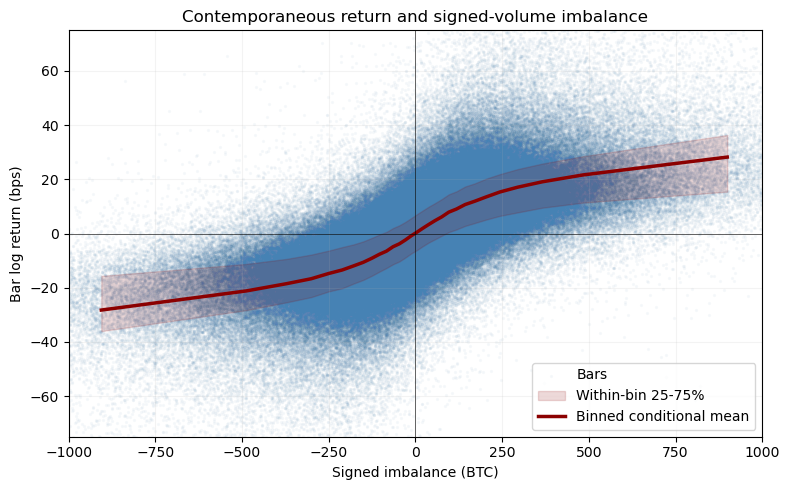

,mean_signed_imbalance,mean_log_return,median_log_return,p25_log_return,p75_log_return,count
0,-905.882641,-28.250594,-24.637668,-36.028765,-15.634813,19460
1,-488.284610,-21.197672,-18.943132,-28.306043,-11.229189,19460
2,-371.719181,-18.511731,-16.613809,-25.383059,-9.370708,19460
3,-300.795040,-16.694689,-14.743472,-23.477043,-7.790682,19460
4,-250.289182,-14.755725,-13.114598,-21.366758,-6.312270,19460


In [9]:
plot_data_2 = analysis[["signed_imbalance", "log_return_bps"]].dropna().copy()

N_BINS = 30

plot_data_2["signed_imbalance_bin"] = pd.qcut(
    plot_data_2["signed_imbalance"],
    q=N_BINS,
    duplicates="drop",
)

binned_2 = (
    plot_data_2
    .groupby("signed_imbalance_bin", observed=True)
    .agg(
        mean_signed_imbalance=("signed_imbalance", "mean"),
        mean_log_return=("log_return_bps", "mean"),
        median_log_return=("log_return_bps", "median"),
        p25_log_return=("log_return_bps", lambda x: x.quantile(0.25)),
        p75_log_return=("log_return_bps", lambda x: x.quantile(0.75)),
        count=("log_return_bps", "size"),
    )
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    plot_data_2["signed_imbalance"],
    plot_data_2["log_return_bps"],
    s=2,
    alpha=0.035,
    color="steelblue",
    rasterized=True,
    label="Bars",
)

ax.fill_between(
    binned_2["mean_signed_imbalance"],
    binned_2["p25_log_return"],
    binned_2["p75_log_return"],
    color="darkred",
    alpha=0.15,
    label="Within-bin 25-75%",
)

ax.plot(
    binned_2["mean_signed_imbalance"],
    binned_2["mean_log_return"],
    #marker="o",
    color='darkred',
    linewidth=2.5,
    label="Binned conditional mean",
)

ax.axhline(0, color="black", linewidth=0.7, alpha=0.6)
ax.axvline(0, color="black", linewidth=0.7, alpha=0.6)

ax.set_xlim(-1000, 1000)
ax.set_ylim(-75, 75)

ax.set_xlabel("Signed imbalance (BTC)")
ax.set_ylabel("Bar log return (bps)")
ax.set_title("Contemporaneous return and signed-volume imbalance")
ax.legend()
ax.grid(alpha=0.15)

fig.tight_layout()

fig.savefig(FIGURE_DIR / "02a_impact_curve.pdf", bbox_inches='tight')

plt.show()

binned_2.head()

## Diagnostic: sensitivity of the absolute-response slope

The low-imbalance region contains substantial price movement unrelated to net signed flow. Dropping early bins illustrates that sensitivity; it is not used to choose the primary model or to maximise $R^2$.


In [10]:
binned.head()

,mean_log_abs_imbalance,mean_current_impact,median_current_impact,p25_current_impact,p75_current_impact,count
0,0.434334,0.104977,0.125062,-6.562205,6.731053,9723
1,1.818149,0.460954,0.574343,-6.041442,7.138928,9723
2,2.342294,0.882873,0.985178,-5.708805,7.572609,9722
3,2.683711,1.270743,1.170813,-5.244892,7.468890,9723
4,2.938248,1.415269,1.310330,-5.273268,8.116305,9723


In [11]:
MIN_BIN_NUMBER = 12
binned_filtered = binned.iloc[MIN_BIN_NUMBER:].copy()

mean_bin_fit = fit_regression(
    data=binned_filtered,
    target="mean_current_impact",
    predictors=["mean_log_abs_imbalance"],
    standardise=[],
    hac_lags=None,
)

median_bin_fit = fit_regression(
    data=binned_filtered,
    target="median_current_impact",
    predictors=["mean_log_abs_imbalance"],
    standardise=[],
    hac_lags=None,
)

mean_slope = mean_bin_fit.model.params["mean_log_abs_imbalance"]
median_slope = median_bin_fit.model.params["mean_log_abs_imbalance"]

print(f"Dropped first {MIN_BIN_NUMBER} of {len(binned)} bins")
print(f"Bars used after bin filter: {binned_filtered['count'].sum():,}")
print(f"Binned mean slope:   {mean_slope:.3f}")
print(f"Binned median slope: {median_slope:.3f}")

Dropped first 12 of 60 bins
Bars used after bin filter: 466,683
Binned mean slope:   8.853
Binned median slope: 7.715


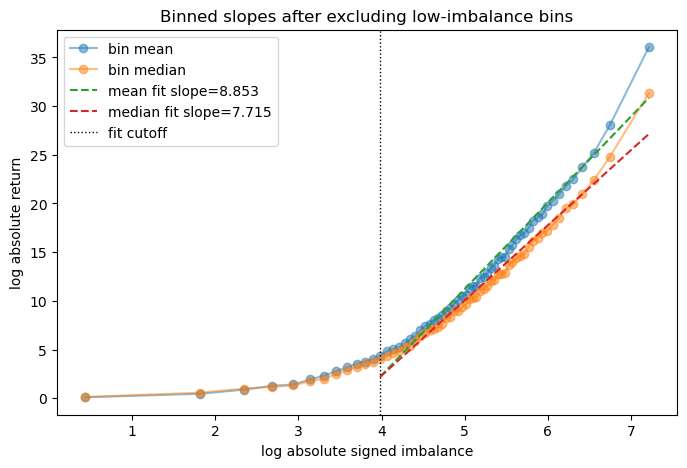

In [12]:
x_grid = np.linspace(
    binned_filtered["mean_log_abs_imbalance"].min(),
    binned_filtered["mean_log_abs_imbalance"].max(),
    100,
)

mean_line = (
    mean_bin_fit.model.params["const"]
    + mean_bin_fit.model.params["mean_log_abs_imbalance"] * x_grid
)
median_line = (
    median_bin_fit.model.params["const"]
    + median_bin_fit.model.params["mean_log_abs_imbalance"] * x_grid
)

plt.figure(figsize=(8, 5))

plt.plot(
    binned["mean_log_abs_imbalance"],
    binned["mean_current_impact"],
    marker="o",
    alpha=0.5,
    label="bin mean",
)
plt.plot(
    binned["mean_log_abs_imbalance"],
    binned["median_current_impact"],
    marker="o",
    alpha=0.5,
    label="bin median",
)
plt.plot(x_grid, mean_line, "--", label=f"mean fit slope={mean_slope:.3f}")
plt.plot(x_grid, median_line, "--", label=f"median fit slope={median_slope:.3f}")
plt.axvline(
    binned.iloc[MIN_BIN_NUMBER]["mean_log_abs_imbalance"],
    color="black",
    linestyle=":",
    linewidth=1,
    label="fit cutoff",
)
plt.xlabel("log absolute signed imbalance")
plt.ylabel("log absolute return")
plt.title("Binned slopes after excluding low-imbalance bins")
plt.legend()

plt.savefig(FIGURE_DIR / "03_binned_slope_fit.pdf")

plt.show()

## Diagnostic: report rather than optimise the cutoff

The table below records how the old absolute-response slope changes across predetermined bin cutoffs. No cutoff is selected from this table for the normalized signed-impact analysis.


In [13]:
rows = []

for min_bin in [0, 3, 6, 9, 12, 15, 18, 21]:
    sample = binned.iloc[min_bin:].copy()
    if len(sample) < 5:
        continue

    mean_fit = fit_regression(
        data=sample,
        target="mean_current_impact",
        predictors=["mean_log_abs_imbalance"],
        standardise=[],
        hac_lags=None,
    )
    median_fit = fit_regression(
        data=sample,
        target="median_current_impact",
        predictors=["mean_log_abs_imbalance"],
        standardise=[],
        hac_lags=None,
    )

    rows.append({
        "min_bin": min_bin,
        "bins_used": len(sample),
        "bars_used": sample["count"].sum(),
        "mean_slope": mean_fit.model.params["mean_log_abs_imbalance"],
        "median_slope": median_fit.model.params["mean_log_abs_imbalance"],
        "mean_r2": mean_fit.model.rsquared,
        "median_r2": median_fit.model.rsquared,
    })

slope_sensitivity = pd.DataFrame(rows)
slope_sensitivity

,min_bin,bins_used,bars_used,mean_slope,median_slope,mean_r2,median_r2
0,0,60,583356,5.615576,4.933250,0.832743,0.837901
1,3,57,554188,7.208483,6.325648,0.933008,0.937960
2,6,54,525019,7.919752,6.932714,0.956397,0.960309
3,9,51,495852,8.443203,7.366042,0.968910,0.971309
4,12,48,466683,8.852589,7.714599,0.976039,0.978166
5,15,45,437517,9.179938,7.986377,0.979797,0.981519
6,18,42,408349,9.430280,8.193080,0.980863,0.982441
7,21,39,379180,9.680264,8.410559,0.981959,0.983785


## Primary estimate: normalized conditional signed impact

For each bar define

$$
x_t=|Q_t|/V^-_{24h},\qquad
y_t=\operatorname{sign}(Q_t)r_t/\sigma^-_{24h}.
$$

The primary curve is $E[y_t\mid x_t]$. Price movements independent of the imbalance direction should tend to cancel in this conditional mean; signing does not, however, separate mechanical impact from news or other common causes of price and order flow.

Thirty equal-count bins give similar precision across the x-range. The conditional mean is the conventional impact object, while the median checks whether the result is dominated by return tails. Ordinary within-bin error bars are shown here; serial dependence is handled by resampling complete days below.


In [14]:
N_IMPACT_BINS = 60
MIN_OBS_PER_FIT_BIN = 500

normalised_sample = analysis[
    ["normalised_imbalance", "normalised_signed_impact"]
].dropna().copy()

normalised_curve = bin_impact_curve_with_uncertainty(
    normalised_sample,
    x_col="normalised_imbalance",
    impact_col="normalised_signed_impact",
    n_bins=N_IMPACT_BINS,
    method="equal_count",
)

normalised_curve[
    [
        "bin_id",
        "mean_x",
        "mean_impact",
        "median_impact",
        "standard_error",
        "n_obs",
    ]
]


,bin_id,mean_x,mean_impact,median_impact,standard_error,n_obs
0,0,0.000006,0.000567,0.000577,0.000327,9605
1,1,0.000017,0.001215,0.001425,0.000326,9604
2,2,0.000028,0.002429,0.002874,0.000330,9605
3,3,0.000039,0.003778,0.004381,0.000325,9604
4,4,0.000050,0.005028,0.005881,0.000332,9605
5,5,0.000062,0.005815,0.006691,0.000329,9604
6,6,0.000073,0.007310,0.007782,0.000328,9605
7,7,0.000084,0.007949,0.008936,0.000325,9604
8,8,0.000096,0.008929,0.009810,0.000328,9605
9,9,0.000108,0.009887,0.010383,0.000321,9604


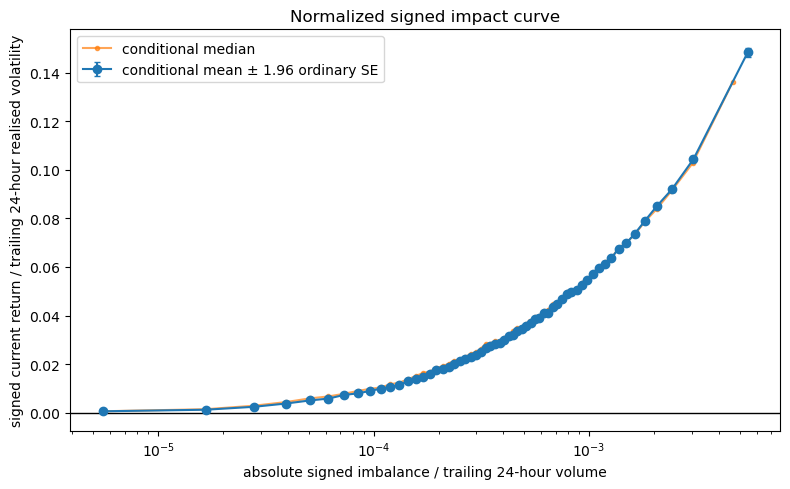

In [15]:
plt.figure(figsize=(8, 5))
plt.errorbar(
    normalised_curve["mean_x"],
    normalised_curve["mean_impact"],
    yerr=1.96 * normalised_curve["standard_error"],
    marker="o",
    capsize=2,
    label="conditional mean ± 1.96 ordinary SE",
)
plt.plot(
    normalised_curve["median_x"],
    normalised_curve["median_impact"],
    marker=".",
    alpha=0.7,
    label="conditional median",
)
plt.axhline(0, color="black", linewidth=1)
plt.xscale("log")
plt.xlabel("absolute signed imbalance / trailing 24-hour volume")
plt.ylabel("signed current return / trailing 24-hour realised volatility")
plt.title("Normalized signed impact curve")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "04_normalised_signed_impact_curve.pdf", bbox_inches="tight")
plt.show()


## Consistent functional-form comparison

Every subsequent pooled, monthly, bootstrap and regime comparison uses the same estimator: nonlinear weighted least squares in impact levels, with inverse within-bin variance weights.

The alternatives are a fixed square root, a freely estimated power law, a fixed linear response and a two-parameter logarithmic response. Errors are evaluated in impact levels. The logarithmic and free-power models have the same number of fitted parameters, making their error comparison particularly useful.


In [16]:
model_curve = normalised_curve.loc[
    normalised_curve["n_obs"] >= MIN_OBS_PER_FIT_BIN
].copy()

model_comparison, model_predictions = compare_impact_models(
    model_curve,
    min_obs_per_bin=MIN_OBS_PER_FIT_BIN,
)
model_comparison.sort_values("weighted_rmse")


,model,amplitude,delta,curvature,rmse,weighted_rmse,mae,bins_used
3,logarithmic,0.056377,NaN,0.713655,0.002234,0.001046,0.000834,60
1,free_power,4.967643,0.655675,NaN,0.002711,0.002005,0.001851,60
0,square_root,1.633052,0.500000,NaN,0.006583,0.005442,0.005155,60
2,linear,47.845816,1.000000,NaN,0.017761,0.010521,0.010257,60


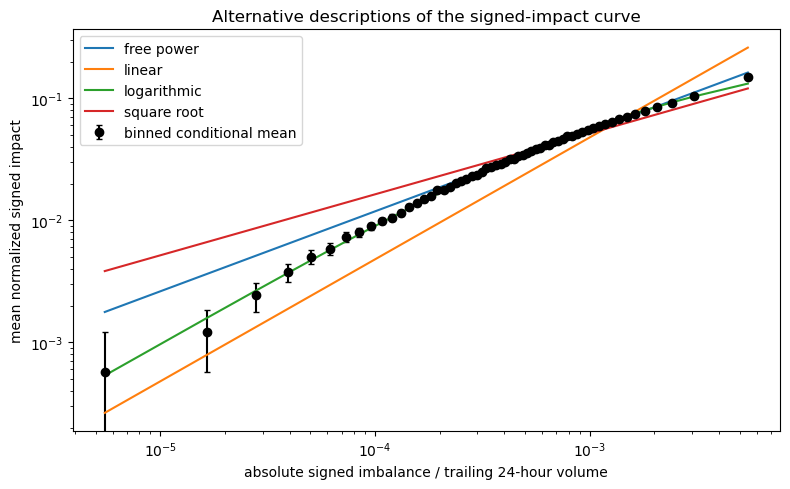

In [17]:
plt.figure(figsize=(8, 5))
plt.errorbar(
    model_curve["mean_x"],
    model_curve["mean_impact"],
    yerr=1.96 * model_curve["standard_error"],
    fmt="o",
    color="black",
    capsize=2,
    label="binned conditional mean",
)
for model, group in model_predictions.groupby("model", observed=True):
    group = group.sort_values("x")
    plt.plot(group["x"], group["predicted_impact"], label=model.replace("_", " "))

plt.xscale("log")
plt.yscale("log")
plt.xlabel("absolute signed imbalance / trailing 24-hour volume")
plt.ylabel("mean normalized signed impact")
plt.title("Alternative descriptions of the signed-impact curve")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "05_normalised_impact_model_comparison.pdf", bbox_inches="tight")
plt.show()


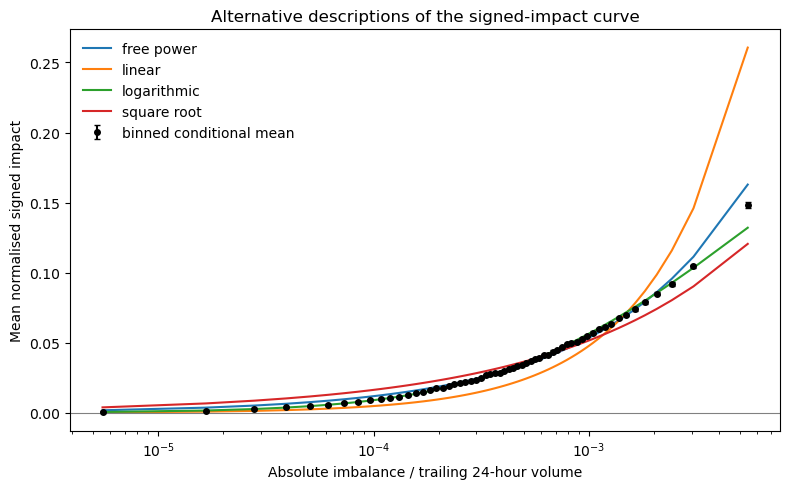

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))

confidence_multiplier = 1.96
yerr = confidence_multiplier * model_curve["standard_error"]

ax.errorbar(
    model_curve["mean_x"],
    model_curve["mean_impact"],
    yerr=yerr,
    fmt="o",
    color="black",
    markersize=4,
    capsize=2,
    label="binned conditional mean",
)

for model, group in model_predictions.groupby("model", observed=True):
    group = group.sort_values("x")
    ax.plot(
        group["x"],
        group["predicted_impact"],
        label=model.replace("_", " "),
    )

ax.set_xscale("log")
ax.axhline(0, color="grey", linewidth=0.8)

ax.set_xlabel(
    "Absolute imbalance / trailing 24-hour volume"
)
ax.set_ylabel("Mean normalised signed impact")
ax.set_title("Alternative descriptions of the signed-impact curve")
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "05_linear_axis_normalised_impact_model_comparison.pdf",
    bbox_inches="tight",
)
plt.show()

### Residual structure

The standardized residual is $(\bar{y}-\hat{y})/\operatorname{SE}(\bar{y})$. A satisfactory curve should leave residuals without a systematic shape across normalized imbalance. Long runs above or below zero indicate that the functional form is missing curvature even when its overall error is small.


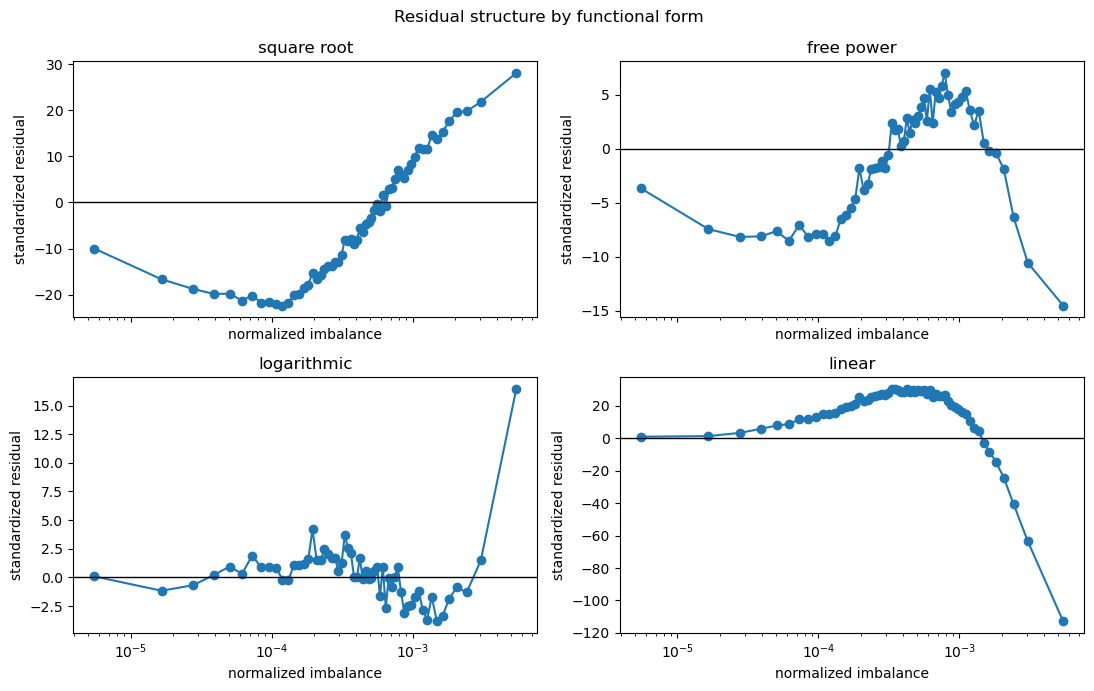

In [19]:
observed_bins = model_curve[
    ["mean_x", "mean_impact", "standard_error"]
].rename(columns={"mean_x": "x"})
model_residuals = model_predictions.merge(observed_bins, on="x", how="left")
model_residuals["standardised_residual"] = (
    model_residuals["mean_impact"] - model_residuals["predicted_impact"]
) / model_residuals["standard_error"]

model_order = ["square_root", "free_power", "logarithmic", "linear"]
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
for model, ax in zip(model_order, axes.ravel(), strict=True):
    group = model_residuals.loc[model_residuals["model"] == model].sort_values("x")
    ax.plot(group["x"], group["standardised_residual"], marker="o")
    ax.axhline(0, color="black", linewidth=1)
    ax.set_xscale("log")
    ax.set_title(model.replace("_", " "))
    ax.set_ylabel("standardized residual")
    ax.set_xlabel("normalized imbalance")

fig.suptitle("Residual structure by functional form")
fig.tight_layout()
plt.savefig(FIGURE_DIR / "05b_model_standardised_residuals.pdf", bbox_inches="tight")
plt.show()


## Stability across months using the same estimator

Each month is independently rebinned and evaluated with the same weighted level-fit comparison used for the pooled sample. The table reports both the free-power exponent and the difference

$$
\mathrm{WRMSE}_{log}-\mathrm{WRMSE}_{power}.
$$

A negative difference means that the logarithmic curve fits that month better. Monthly x-ranges and sample sizes should be considered when interpreting unstable estimates.


In [20]:
monthly_analysis = analysis.copy()
monthly_rows = []

monthly_analysis["calendar_month"] = (
    monthly_analysis.index
    .tz_localize(None).to_period("M")
                                   )

for calendar_month, month in monthly_analysis.groupby(
    "calendar_month",
    observed=True,
):
    month_sample = month[
            ["normalised_imbalance", "normalised_signed_impact"]
        ].dropna()
    if len(month_sample) < 2_000:
            continue

    month_curve = bin_impact_curve_with_uncertainty(
        month_sample,
        x_col="normalised_imbalance",
        impact_col="normalised_signed_impact",
        n_bins=20,
        method="equal_count",
    )
    try:
        month_comparison, _ = compare_impact_models(
            month_curve,
            min_obs_per_bin=100,
        )
    except (RuntimeError, ValueError):
        continue

    fitted = month_comparison.set_index("model")
    monthly_rows.append(
        {
            "calendar_month": str(calendar_month),
            "observations": len(month_sample),
            "min_x": month_sample["normalised_imbalance"].min(),
            "max_x": month_sample["normalised_imbalance"].max(),
            "free_power_delta": fitted.loc["free_power", "delta"],
            "free_power_weighted_rmse": fitted.loc["free_power", "weighted_rmse"],
            "logarithmic_curvature": fitted.loc["logarithmic", "curvature"],
            "logarithmic_weighted_rmse": fitted.loc["logarithmic", "weighted_rmse"],
            "square_root_weighted_rmse": fitted.loc["square_root", "weighted_rmse"],
            "log_relative_improvement_pct": 100 * (
                (- fitted.loc["logarithmic", "weighted_rmse"]
                + fitted.loc["free_power", "weighted_rmse"] 
                ) / fitted.loc["free_power", "weighted_rmse"] 
            ),
        }
    )

monthly_model_comparison = pd.DataFrame(monthly_rows)
monthly_model_comparison

,calendar_month,observations,min_x,max_x,free_power_delta,free_power_weighted_rmse,logarithmic_curvature,logarithmic_weighted_rmse,square_root_weighted_rmse,log_relative_improvement_pct
0,2021-01,10039,0.000000,0.006241,0.706307,0.002270,0.613166,0.001462,0.006562,35.596821
1,2021-02,8909,0.000000,0.006934,0.719422,0.001877,0.528666,0.001702,0.006767,9.299879
2,2021-03,9814,0.000000,0.004951,0.692321,0.002368,0.688442,0.001634,0.006187,31.025535
3,2021-04,7745,0.000000,0.007823,0.729413,0.003014,0.506800,0.002293,0.007951,23.917580
4,2021-05,15895,0.000000,0.007666,0.680003,0.002092,0.618478,0.001218,0.004947,41.768253
...,...,...,...,...,...,...,...,...,...,...
63,2026-04,5340,0.000000,0.024030,0.621648,0.004676,0.910347,0.002610,0.006685,44.189192
64,2026-05,4515,0.000001,0.031738,0.595763,0.005286,1.135147,0.003231,0.006689,38.872696
65,2026-06,7069,0.000000,0.022039,0.595195,0.004071,1.077600,0.002747,0.005331,32.536159
66,2026-07,4532,0.000000,0.027618,0.616359,0.004745,0.853111,0.003001,0.006906,36.756121


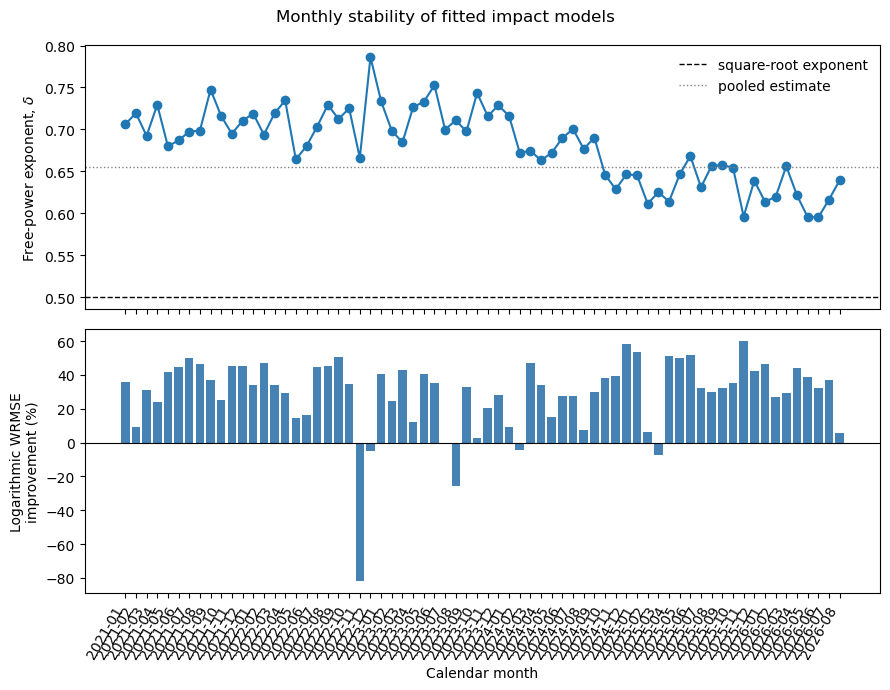

In [21]:
monthly_model_comparison = (
    pd.DataFrame(monthly_rows)
    .sort_values("calendar_month")
    .reset_index(drop=True)
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(9, 7),
    sharex=True,
)

positions = np.arange(len(monthly_model_comparison))
labels = monthly_model_comparison["calendar_month"]

axes[0].plot(
    positions,
    monthly_model_comparison["free_power_delta"],
    marker="o",
    linewidth=1.5,
)

axes[0].axhline(
    0.5,
    color="black",
    linestyle="--",
    linewidth=1,
    label="square-root exponent",
)

axes[0].axhline(
    model_comparison
    .set_index("model")
    .loc["free_power", "delta"],
    color="grey",
    linestyle=":",
    linewidth=1,
    label="pooled estimate",
)

axes[0].set_ylabel(r"Free-power exponent, $\delta$")
axes[0].legend(frameon=False)

axes[1].bar(
    positions,
    monthly_model_comparison["log_relative_improvement_pct"],
    color="steelblue",
)

axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("Logarithmic WRMSE\nimprovement (%)")
axes[1].set_xticks(positions)
axes[1].set_xticklabels(labels, rotation=60, ha="right")
axes[1].set_xlabel("Calendar month")

fig.suptitle("Monthly stability of fitted impact models")
fig.tight_layout()

fig.savefig(
    FIGURE_DIR / "06_monthly_model_stability.pdf",
    bbox_inches="tight",
)

plt.show()

In [22]:
monthly_summary = pd.Series(
    {
        "months": len(monthly_model_comparison),
        "mean_delta": monthly_model_comparison[
            "free_power_delta"
        ].mean(),
        "sd_delta": monthly_model_comparison[
            "free_power_delta"
        ].std(),
        "minimum_delta": monthly_model_comparison[
            "free_power_delta"
        ].min(),
        "maximum_delta": monthly_model_comparison[
            "free_power_delta"
        ].max(),
        "months_log_better": (
            monthly_model_comparison[
                "log_relative_improvement_pct"
            ] > 0
        ).sum(),
        "median_log_improvement_pct": monthly_model_comparison[
            "log_relative_improvement_pct"
        ].median(),
    }
)

monthly_summary

months                       68.000000
mean_delta                    0.681171
sd_delta                      0.043324
minimum_delta                 0.595195
maximum_delta                 0.786112
months_log_better            62.000000
median_log_improvement_pct   33.881585
dtype: float64

## Day-block bootstrap of the complete estimator

Bars are serially dependent, so the bootstrap resamples complete UTC days. Every bootstrap sample reconstructs the equal-count curve and repeats the same weighted level-fit comparison.

The output gives an uncertainty interval for the free-power exponent and the frequency with which the logarithmic curve beats the free power law. This evaluates estimator stability; it does not turn the aggregate-flow association into a causal impact estimate.


In [23]:
N_BOOTSTRAP = 200

bootstrap_results = block_bootstrap_impact_models(
    analysis,
    block_col="block_day",
    x_col="normalised_imbalance",
    impact_col="normalised_signed_impact",
    n_bins=N_IMPACT_BINS,
    n_bootstrap=N_BOOTSTRAP,
    min_obs_per_bin=MIN_OBS_PER_FIT_BIN,
    random_state=2026,
)

bootstrap_summary = pd.Series(
    {
        "successful_samples": len(bootstrap_results),
        "median_free_power_delta": bootstrap_results["free_power_delta"].median(),
        "delta_ci_2.5%": bootstrap_results["free_power_delta"].quantile(0.025),
        "delta_ci_97.5%": bootstrap_results["free_power_delta"].quantile(0.975),
        "median_log_minus_power_wrmse": bootstrap_results[
            "log_minus_power_weighted_rmse"
        ].median(),
        "probability_log_better": (
            bootstrap_results["log_minus_power_weighted_rmse"] < 0
        ).mean(),
    },
    name="day-block bootstrap",
)
bootstrap_summary


successful_samples             200.000000
median_free_power_delta          0.656507
delta_ci_2.5%                    0.650710
delta_ci_97.5%                   0.661177
median_log_minus_power_wrmse    -0.000928
probability_log_better           1.000000
Name: day-block bootstrap, dtype: float64

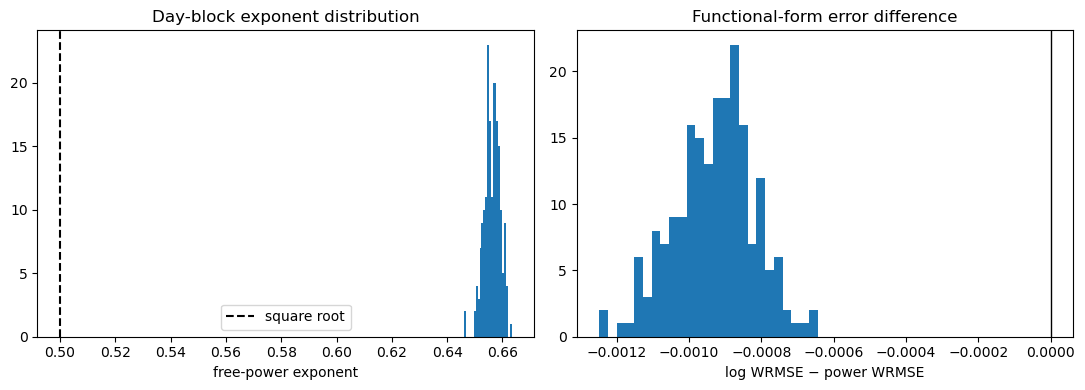

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(bootstrap_results["free_power_delta"], bins=25)
axes[0].axvline(0.5, color="black", linestyle="--", label="square root")
axes[0].set_xlabel("free-power exponent")
axes[0].set_title("Day-block exponent distribution")
axes[0].legend()

axes[1].hist(bootstrap_results["log_minus_power_weighted_rmse"], bins=25)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_xlabel("log WRMSE − power WRMSE")
axes[1].set_title("Functional-form error difference")

fig.tight_layout()
plt.show()


## Liquidity-state comparisons on common support

Volume, flow rate and duration describe different aspects of market activity:

- gross volume is BTC traded in the fixed 4,000-event bar;
- flow rate is gross BTC per second relative to the trailing 24-hour average BTC-per-second rate;
- duration is the clock time needed to accumulate the 4,000 events.

All regime curves below use pooled normalized-imbalance edges. Model comparisons retain only bins represented in every regime, so differences are not produced solely by fitting different x-ranges.


### Gross-volume state

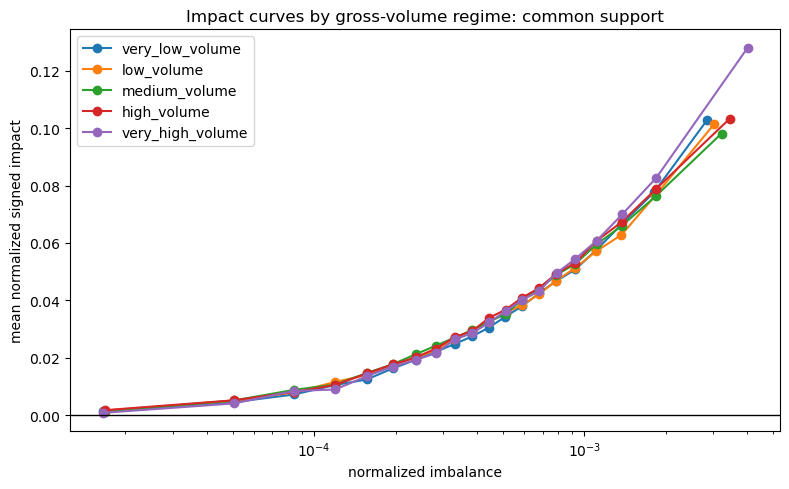

,volume_regime,model,delta,weighted_rmse,bins_used
15,high_volume,logarithmic,NaN,0.000470,20
13,high_volume,free_power,0.620485,0.002751,20
12,high_volume,square_root,0.500000,0.004891,20
14,high_volume,linear,1.000000,0.011779,20
7,low_volume,logarithmic,NaN,0.000804,20
5,low_volume,free_power,0.658475,0.001732,20
4,low_volume,square_root,0.500000,0.004639,20
6,low_volume,linear,1.000000,0.008413,20
11,medium_volume,logarithmic,NaN,0.000518,20
9,medium_volume,free_power,0.631792,0.002382,20


In [25]:
volume_order = [
    "very_low_volume", "low_volume", "medium_volume", "high_volume", "very_high_volume"
]
volume_curves, _ = bin_impact_by_shared_edges(
    analysis,
    regime_col="volume_regime",
    x_col="normalised_imbalance",
    impact_col="normalised_signed_impact",
    n_bins=20,
    min_obs_per_cell=200,
)
volume_model_comparison, _, common_volume_curves = compare_impact_models_by_regime(
    volume_curves,
    regime_col="volume_regime",
    regimes=volume_order,
    min_obs_per_bin=200,
)

plt.figure(figsize=(8, 5))
for regime in volume_order:
    group = common_volume_curves.loc[common_volume_curves["volume_regime"] == regime]
    plt.plot(group["mean_x"], group["mean_impact"], marker="o", label=regime)
plt.axhline(0, color="black", linewidth=1)
plt.xscale("log")
plt.xlabel("normalized imbalance")
plt.ylabel("mean normalized signed impact")
plt.title("Impact curves by gross-volume regime: common support")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "06_volume_regime_scaling_collapse.pdf", bbox_inches="tight")
plt.show()

volume_model_comparison[
    ["volume_regime", "model", "delta", "weighted_rmse", "bins_used"]
].sort_values(["volume_regime", "weighted_rmse"])


### Normalized flow-rate state

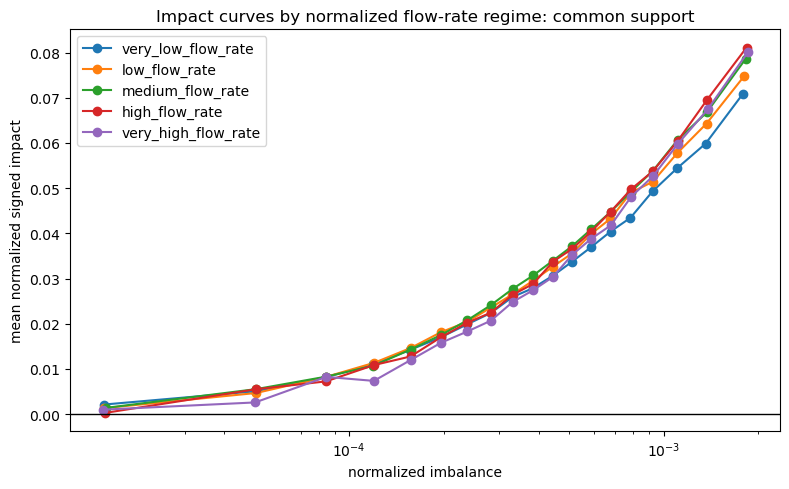

,flow_rate_regime,model,delta,weighted_rmse,bins_used
15,high_flow_rate,logarithmic,NaN,0.000613,19
13,high_flow_rate,free_power,0.689334,0.001840,19
12,high_flow_rate,square_root,0.500000,0.005437,19
14,high_flow_rate,linear,1.000000,0.007349,19
7,low_flow_rate,logarithmic,NaN,0.000458,19
5,low_flow_rate,free_power,0.674458,0.001686,19
4,low_flow_rate,square_root,0.500000,0.004375,19
6,low_flow_rate,linear,1.000000,0.006723,19
11,medium_flow_rate,logarithmic,NaN,0.000428,19
9,medium_flow_rate,free_power,0.669620,0.001821,19


In [26]:
flow_rate_order = [
    "very_low_flow_rate", "low_flow_rate", "medium_flow_rate",
    "high_flow_rate", "very_high_flow_rate"
]
flow_rate_curves, _ = bin_impact_by_shared_edges(
    analysis,
    regime_col="flow_rate_regime",
    x_col="normalised_imbalance",
    impact_col="normalised_signed_impact",
    n_bins=20,
    min_obs_per_cell=200,
)
flow_rate_model_comparison, _, common_flow_rate_curves = compare_impact_models_by_regime(
    flow_rate_curves,
    regime_col="flow_rate_regime",
    regimes=flow_rate_order,
    min_obs_per_bin=200,
)

plt.figure(figsize=(8, 5))
for regime in flow_rate_order:
    group = common_flow_rate_curves.loc[
        common_flow_rate_curves["flow_rate_regime"] == regime
    ]
    plt.plot(group["mean_x"], group["mean_impact"], marker="o", label=regime)
plt.axhline(0, color="black", linewidth=1)
plt.xscale("log")
plt.xlabel("normalized imbalance")
plt.ylabel("mean normalized signed impact")
plt.title("Impact curves by normalized flow-rate regime: common support")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "07_flow_rate_regime_impact_curves.pdf", bbox_inches="tight")
plt.show()

flow_rate_model_comparison[
    ["flow_rate_regime", "model", "delta", "weighted_rmse", "bins_used"]
].sort_values(["flow_rate_regime", "weighted_rmse"])


### Duration state

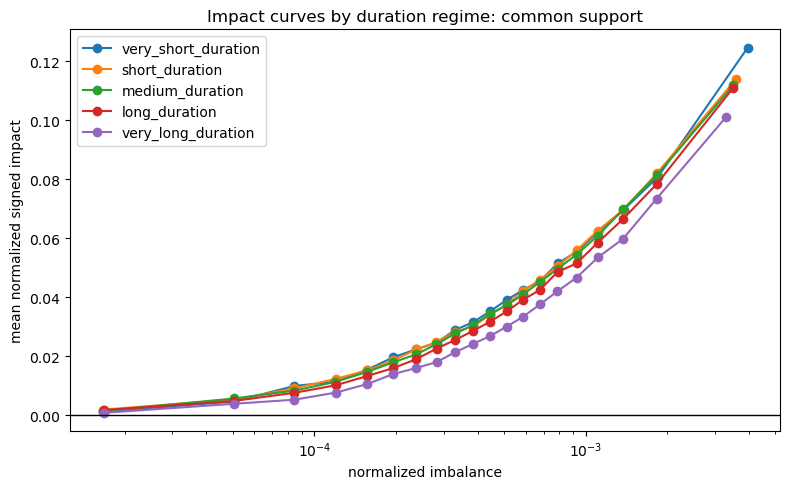

,duration_regime,model,delta,weighted_rmse,bins_used
15,long_duration,logarithmic,NaN,0.000563,20
13,long_duration,free_power,0.666538,0.002127,20
12,long_duration,square_root,0.500000,0.005466,20
14,long_duration,linear,1.000000,0.009451,20
11,medium_duration,logarithmic,NaN,0.000467,20
9,medium_duration,free_power,0.649644,0.002242,20
8,medium_duration,square_root,0.500000,0.005222,20
10,medium_duration,linear,1.000000,0.010226,20
7,short_duration,logarithmic,NaN,0.000599,20
5,short_duration,free_power,0.636005,0.002266,20


In [27]:
duration_order = [
    "very_short_duration", "short_duration", "medium_duration",
    "long_duration", "very_long_duration"
]
duration_curves, _ = bin_impact_by_shared_edges(
    analysis,
    regime_col="duration_regime",
    x_col="normalised_imbalance",
    impact_col="normalised_signed_impact",
    n_bins=20,
    min_obs_per_cell=200,
)
duration_model_comparison, _, common_duration_curves = compare_impact_models_by_regime(
    duration_curves,
    regime_col="duration_regime",
    regimes=duration_order,
    min_obs_per_bin=200,
)

plt.figure(figsize=(8, 5))
for regime in duration_order:
    group = common_duration_curves.loc[
        common_duration_curves["duration_regime"] == regime
    ]
    plt.plot(group["mean_x"], group["mean_impact"], marker="o", label=regime)
plt.axhline(0, color="black", linewidth=1)
plt.xscale("log")
plt.xlabel("normalized imbalance")
plt.ylabel("mean normalized signed impact")
plt.title("Impact curves by duration regime: common support")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "08_duration_regime_impact_curves.pdf", bbox_inches="tight")
plt.show()

duration_model_comparison[
    ["duration_regime", "model", "delta", "weighted_rmse", "bins_used"]
].sort_values(["duration_regime", "weighted_rmse"])


## Normalized impact trajectories after the imbalance bar

For horizon $h$, total signed impact from the current bar start through the end of bar $t+h$ is

$$
I_t(h)=\frac{\operatorname{sign}(Q_t)r_t+
\operatorname{sign}(Q_t)r_{t\rightarrow t+h}}
{\sigma^-_{24h}}.
$$

The fraction remaining is the ratio of conditional means, $E[I(h)]/E[I(0)]$. A value below one indicates partial reversal; above one indicates continuation. It is deliberately not the mean of individual ratios, which would be unstable whenever initial impact is close to zero.

Horizons are numbers of 4,000-event bars rather than fixed clock time. This is market-event time and must not yet be interpreted as an execution schedule in minutes.


In [28]:
trajectory_horizons = [0, *HORIZONS]

trajectory_by_imbalance = summarise_normalised_impact_trajectory(
    analysis,
    group_cols=["normalised_imbalance_regime"],
    horizons=trajectory_horizons,
)
trajectory_by_flow_rate = summarise_normalised_impact_trajectory(
    analysis,
    group_cols=["flow_rate_regime"],
    horizons=trajectory_horizons,
)
trajectory_by_imbalance_and_flow = summarise_normalised_impact_trajectory(
    analysis,
    group_cols=["normalised_imbalance_regime", "flow_rate_regime"],
    horizons=trajectory_horizons,
)

trajectory_by_imbalance


,normalised_imbalance_regime,horizon,count,mean_total_impact,median_total_impact,impact_std,standard_error,mean_initial_impact,fraction_remaining,fraction_reversed
0,very_low_imbalance,0,115254,0.006243,0.006832,0.032319,0.000095,0.006243,1.000000,0.000000
1,very_low_imbalance,1,115254,0.006083,0.006867,0.061836,0.000182,0.006243,0.974465,0.025535
2,very_low_imbalance,2,115254,0.005881,0.006406,0.080407,0.000237,0.006243,0.942131,0.057869
3,very_low_imbalance,3,115254,0.005813,0.006564,0.096114,0.000283,0.006243,0.931209,0.068791
4,very_low_imbalance,5,115254,0.006044,0.006402,0.120577,0.000355,0.006243,0.968190,0.031810
5,low_imbalance,0,115253,0.018486,0.019444,0.033796,0.000100,0.018486,1.000000,0.000000
6,low_imbalance,1,115253,0.017865,0.019497,0.064057,0.000189,0.018486,0.966436,0.033564
7,low_imbalance,2,115253,0.017814,0.018925,0.083600,0.000246,0.018486,0.963654,0.036346
8,low_imbalance,3,115253,0.017599,0.019067,0.099472,0.000293,0.018486,0.952055,0.047945
9,low_imbalance,5,115253,0.017576,0.018598,0.125326,0.000369,0.018486,0.950813,0.049187


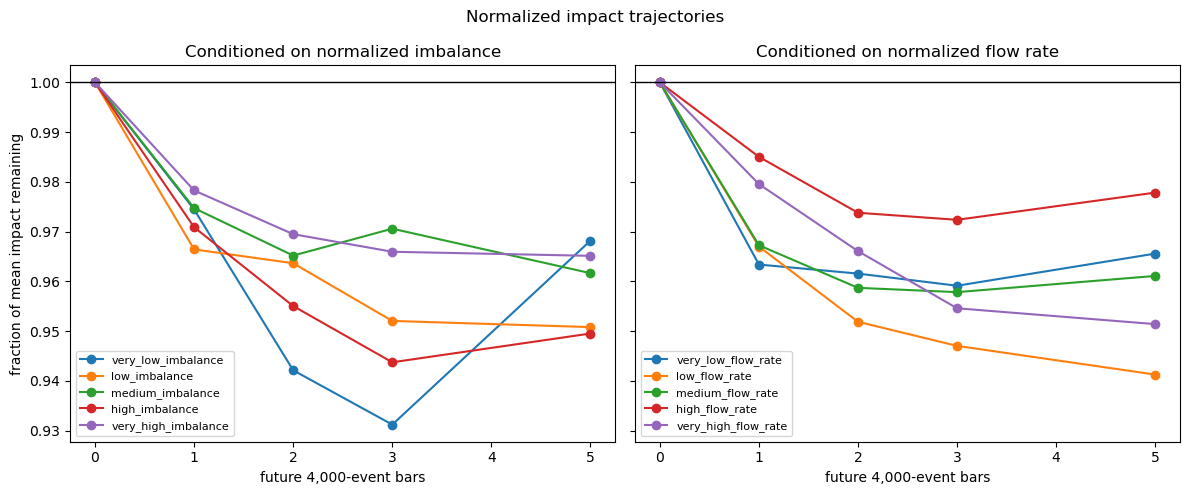

In [29]:
imbalance_order = [
    "very_low_imbalance", "low_imbalance", "medium_imbalance",
    "high_imbalance", "very_high_imbalance"
]
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for regime in imbalance_order:
    group = trajectory_by_imbalance.loc[
        trajectory_by_imbalance["normalised_imbalance_regime"] == regime
    ]
    axes[0].plot(group["horizon"], group["fraction_remaining"], marker="o", label=regime)
axes[0].axhline(1, color="black", linewidth=1)
axes[0].set_title("Conditioned on normalized imbalance")
axes[0].set_xlabel("future 4,000-event bars")
axes[0].set_ylabel("fraction of mean impact remaining")

for regime in flow_rate_order:
    group = trajectory_by_flow_rate.loc[
        trajectory_by_flow_rate["flow_rate_regime"] == regime
    ]
    axes[1].plot(group["horizon"], group["fraction_remaining"], marker="o", label=regime)
axes[1].axhline(1, color="black", linewidth=1)
axes[1].set_title("Conditioned on normalized flow rate")
axes[1].set_xlabel("future 4,000-event bars")

axes[0].legend(fontsize=8)
axes[1].legend(fontsize=8)
fig.suptitle("Normalized impact trajectories")
fig.tight_layout()
plt.savefig(FIGURE_DIR / "09_normalised_impact_trajectories.pdf", bbox_inches="tight")
plt.show()


In [30]:
horizon_to_display = max(HORIZONS)
trajectory_state_table = trajectory_by_imbalance_and_flow.loc[
    trajectory_by_imbalance_and_flow["horizon"] == horizon_to_display
].pivot(
    index="normalised_imbalance_regime",
    columns="flow_rate_regime",
    values="fraction_remaining",
).reindex(index=imbalance_order, columns=flow_rate_order)

trajectory_state_table


flow_rate_regime,very_low_flow_rate,low_flow_rate,medium_flow_rate,high_flow_rate,very_high_flow_rate
normalised_imbalance_regime,,,,,
very_low_imbalance,1.051637,1.025978,0.601903,1.240970,0.849322
low_imbalance,0.978096,0.924952,0.942031,0.944913,0.968462
medium_imbalance,0.949815,0.950154,0.981174,1.004635,0.904706
high_imbalance,0.956612,0.917209,0.974703,0.966688,0.928966
very_high_imbalance,0.930105,0.955273,0.980894,0.968379,0.962782


## Interpretation and limits

The central result is a smooth, monotonic and concave normalized signed-flow response. Mean and median impact should be considered together to establish whether the result is broad-based rather than tail-driven. The free-power exponent is an interpretable summary elasticity, while the logarithmic-versus-power error comparison tests whether that elasticity is actually constant.

The monthly, day-block and common-support regime sections determine how stable this description is. In particular, persistent separation by flow rate would show that volume and imbalance alone do not characterize liquidity: the speed at which flow arrives changes the response.

The trajectory section is a first estimate of response over market-event time. It distinguishes continuation from partial reversal and conditions that behaviour on imbalance and flow-rate state. It is not yet an optimal-execution cost model because:

- the bars contain anonymous aggregate flow rather than identified parent orders;
- contemporaneous association does not establish the causal effect of adding a firm's order;
- transaction prices include bid-offer and endpoint effects;
- BTCUSDT perpetual-futures flow can include liquidations and basis-related activity;
- the trajectory horizons are event bars, not clock time;
- trajectory uncertainty still needs a block-bootstrap extension.

The defensible conclusion is evidence for a state-dependent concave aggregate-flow response. The next practical extension is to estimate the same trajectory in clock time, add spread and fee estimates, and relate a proposed firm's participation rate to expected cost and inventory risk.


In [31]:
analysis["event_speed_regime"] = pd.qcut(
    analysis["duration_seconds"],
    q=5,
    labels=[
        "very_fast",
        "fast",
        "medium",
        "slow",
        "very_slow",
    ],
)

In [32]:
speed_curves, speed_edges = bin_impact_by_shared_edges(
    analysis,
    regime_col="event_speed_regime",
    x_col="normalised_imbalance",
    impact_col="normalised_signed_impact",
    n_bins=20,
    min_obs_per_cell=200,
)

pooled_x_scale = float(analysis["normalised_imbalance"].dropna().median())

In [33]:
speed_order = [
    "very_fast",
    "fast",
    "medium",
    "slow",
    "very_slow",
]

speed_model_comparison, speed_predictions, common_speed_curves = (
    compare_impact_models_by_regime(
        speed_curves,
        regime_col="event_speed_regime",
        regimes=speed_order,
        min_obs_per_bin=200,
        require_common_bins=True,
        x_scale=pooled_x_scale,
    )
)

In [34]:
regime_summary = (
    speed_model_comparison
    .pivot(
        index="event_speed_regime",
        columns="model",
        values=[
            "amplitude",
            "delta",
            "curvature",
            "weighted_rmse",
        ],
    )
)

log_A = regime_summary[("amplitude", "logarithmic")]
log_b = regime_summary[("curvature", "logarithmic")]

regime_parameters = pd.DataFrame(
    {
        "log_amplitude": log_A,
        "log_curvature": log_b,
        "log_x0": pooled_x_scale / log_b,
        "free_power_delta": regime_summary[
            ("delta", "free_power")
        ],
        "log_wrmse": regime_summary[
            ("weighted_rmse", "logarithmic")
        ],
        "power_wrmse": regime_summary[
            ("weighted_rmse", "free_power")
        ],
    }
)

regime_parameters["initial_marginal_impact"] = (
    regime_parameters["log_amplitude"]
    / regime_parameters["log_x0"]
)

regime_parameters["initial_effective_liquidity"] = (
    regime_parameters["log_x0"]
    / regime_parameters["log_amplitude"]
)

regime_parameters["log_wrmse_improvement_pct"] = 100 * (
    regime_parameters["power_wrmse"]
    - regime_parameters["log_wrmse"]
) / regime_parameters["power_wrmse"]

regime_parameters

,log_amplitude,log_curvature,log_x0,free_power_delta,log_wrmse,power_wrmse,initial_marginal_impact,initial_effective_liquidity,log_wrmse_improvement_pct
event_speed_regime,,,,,,,,,
fast,0.051434,0.887879,0.000465,0.636005,0.000599,0.002266,110.573859,0.009044,73.570637
medium,0.052170,0.845907,0.000488,0.649644,0.000467,0.002242,106.853242,0.009359,79.185695
slow,0.055517,0.710933,0.000581,0.666538,0.000563,0.002127,95.566023,0.010464,73.532052
very_fast,0.053743,0.840410,0.000491,0.618738,0.001427,0.002396,109.359901,0.009144,40.436168
very_slow,0.063361,0.489487,0.000844,0.707138,0.000492,0.001976,75.094424,0.013317,75.115747


In [35]:
reference_x = float(
    analysis["normalised_imbalance"].quantile(0.90)
)

regime_parameters["impact_at_reference_x"] = (
    regime_parameters["log_amplitude"]
    * np.log1p(
        reference_x / regime_parameters["log_x0"]
    )
)

z = reference_x / regime_parameters["log_x0"]

regime_parameters["elasticity_at_reference_x"] = (
    (z / (1 + z)) / np.log1p(z)
)

regime_parameters

,log_amplitude,log_curvature,log_x0,free_power_delta,log_wrmse,power_wrmse,initial_marginal_impact,initial_effective_liquidity,log_wrmse_improvement_pct,impact_at_reference_x,elasticity_at_reference_x
event_speed_regime,,,,,,,,,,,
fast,0.051434,0.887879,0.000465,0.636005,0.000599,0.002266,110.573859,0.009044,73.570637,0.075558,0.524057
medium,0.052170,0.845907,0.000488,0.649644,0.000467,0.002242,106.853242,0.009359,79.185695,0.074704,0.531554
slow,0.055517,0.710933,0.000581,0.666538,0.000563,0.002127,95.566023,0.010464,73.532052,0.072309,0.559048
very_fast,0.053743,0.840410,0.000491,0.618738,0.001427,0.002396,109.359901,0.009144,40.436168,0.076691,0.532569
very_slow,0.063361,0.489487,0.000844,0.707138,0.000492,0.001976,75.094424,0.013317,75.115747,0.066227,0.620330


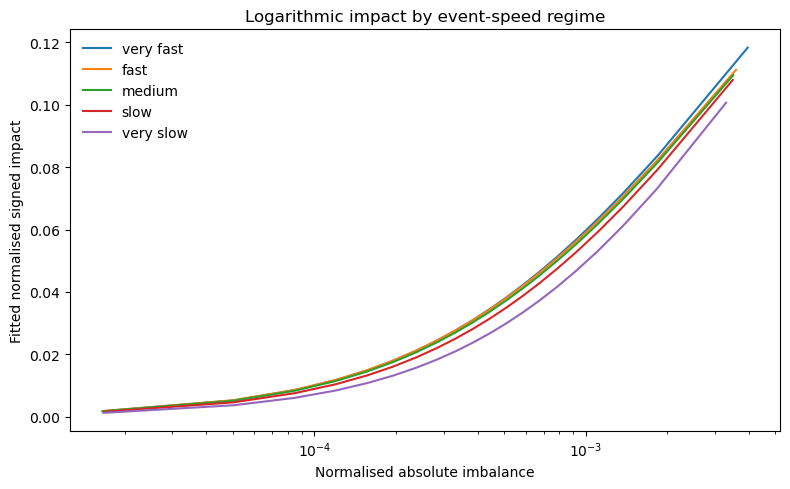

In [36]:
fig, ax = plt.subplots(figsize=(8, 5))

for regime in speed_order:
    group = speed_predictions.loc[
        (speed_predictions["event_speed_regime"] == regime)
        & (speed_predictions["model"] == "logarithmic")
    ].sort_values("x")

    ax.plot(
        group["x"],
        group["predicted_impact"],
        label=regime.replace("_", " "),
    )

ax.set_xscale("log")
ax.set_xlabel("Normalised absolute imbalance")
ax.set_ylabel("Fitted normalised signed impact")
ax.set_title("Logarithmic impact by event-speed regime")
ax.legend(frameon=False)

fig.tight_layout()
plt.show()

In [37]:
volume_order = [
    "very_low_volume", "low_volume", "medium_volume", "high_volume", "very_high_volume"
]
volume_curves, _ = bin_impact_by_shared_edges(
    analysis,
    regime_col="volume_regime",
    x_col="normalised_imbalance",
    impact_col="normalised_signed_impact",
    n_bins=20,
    min_obs_per_cell=200,
)
volume_model_comparison, volume_predictions, common_volume_curves = compare_impact_models_by_regime(
    volume_curves,
    regime_col="volume_regime",
    regimes=volume_order,
    min_obs_per_bin=200,
    x_scale=pooled_x_scale,
)


In [38]:
regime_summary_vol = (
    volume_model_comparison
    .pivot(
        index="volume_regime",
        columns="model",
        values=[
            "amplitude",
            "delta",
            "curvature",
            "weighted_rmse",
        ],
    )
)

log_A = regime_summary_vol[("amplitude", "logarithmic")]
log_b = regime_summary_vol[("curvature", "logarithmic")]

regime_parameters_vol = pd.DataFrame(
    {
        "log_amplitude": log_A,
        "log_curvature": log_b,
        "log_x0": pooled_x_scale / log_b,
        "free_power_delta": regime_summary_vol[
            ("delta", "free_power")
        ],
        "log_wrmse": regime_summary_vol[
            ("weighted_rmse", "logarithmic")
        ],
        "power_wrmse": regime_summary_vol[
            ("weighted_rmse", "free_power")
        ],
    }
)

regime_parameters_vol["initial_marginal_impact"] = (
    regime_parameters_vol["log_amplitude"]
    / regime_parameters_vol["log_x0"]
)

regime_parameters_vol["initial_effective_liquidity"] = (
    regime_parameters_vol["log_x0"]
    / regime_parameters_vol["log_amplitude"]
)

regime_parameters_vol["log_wrmse_improvement_pct"] = 100 * (
    regime_parameters_vol["power_wrmse"]
    - regime_parameters_vol["log_wrmse"]
) / regime_parameters_vol["power_wrmse"]

regime_parameters_vol

,log_amplitude,log_curvature,log_x0,free_power_delta,log_wrmse,power_wrmse,initial_marginal_impact,initial_effective_liquidity,log_wrmse_improvement_pct
volume_regime,,,,,,,,,
high_volume,0.047836,0.933084,0.000443,0.620485,0.000470,0.002751,108.074359,0.009253,82.918312
low_volume,0.046499,0.926324,0.000446,0.658475,0.000804,0.001732,104.291328,0.009589,53.611425
medium_volume,0.044656,1.021047,0.000404,0.631792,0.000518,0.002382,110.400660,0.009058,78.273662
very_high_volume,0.067358,0.559180,0.000739,0.643931,0.000977,0.002531,91.198055,0.010965,61.380485
very_low_volume,0.055897,0.687853,0.000600,0.709995,0.000551,0.001455,93.096003,0.010742,62.100396


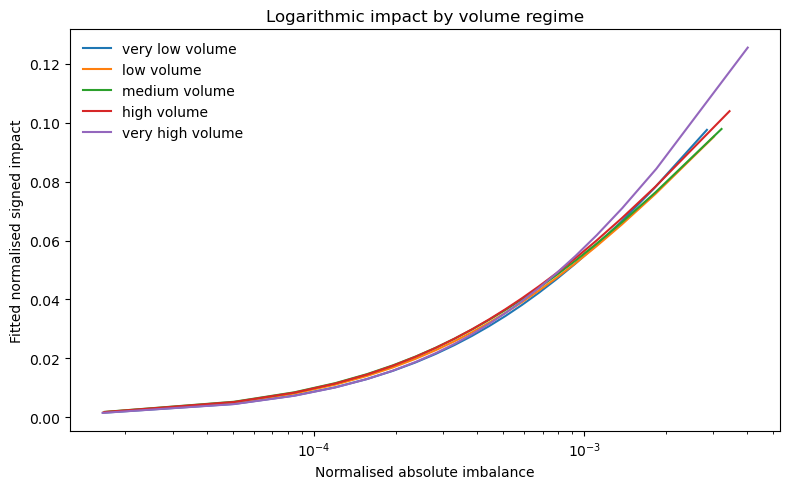

In [39]:
fig, ax = plt.subplots(figsize=(8, 5))

for regime in volume_order:
    group = volume_predictions.loc[
        (volume_predictions["volume_regime"] == regime)
        & (volume_predictions["model"] == "logarithmic")
    ].sort_values("x")

    ax.plot(
        group["x"],
        group["predicted_impact"],
        label=regime.replace("_", " "),
    )

ax.set_xscale("log")
ax.set_xlabel("Normalised absolute imbalance")
ax.set_ylabel("Fitted normalised signed impact")
ax.set_title("Logarithmic impact by volume regime")
ax.legend(frameon=False)

fig.tight_layout()
plt.show()